In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier, XGBRFClassifier

### Consume data

In [15]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

In [16]:
display(train_df.head(10))

,id,gravity,ph,osmo,cond,urea,calc,target
0,0,1.013,6.19,443,14.8,124,1.45,0
1,1,1.025,5.40,703,23.6,394,4.18,0
2,2,1.009,6.13,371,24.5,159,9.04,0
3,3,1.021,4.91,442,20.8,398,6.63,1
4,4,1.021,5.53,874,17.8,385,2.21,1
5,5,1.025,6.90,947,28.4,395,2.64,1
6,6,1.008,5.09,371,15.5,159,2.17,1
7,7,1.015,5.53,450,8.1,170,1.16,0
8,8,1.025,7.38,736,25.3,418,1.52,0
9,9,1.017,6.61,527,20.0,75,4.49,1


In [17]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       414 non-null    int64  
 1   gravity  414 non-null    float64
 2   ph       414 non-null    float64
 3   osmo     414 non-null    int64  
 4   cond     414 non-null    float64
 5   urea     414 non-null    int64  
 6   calc     414 non-null    float64
 7   target   414 non-null    int64  
dtypes: float64(4), int64(4)
memory usage: 26.0 KB


In [18]:
train_df.describe()

,id,gravity,ph,osmo,cond,urea,calc,target
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,206.500000,1.017894,5.955459,651.545894,21.437923,278.657005,4.114638,0.444444
std,119.655756,0.006675,0.642260,234.676567,7.514750,136.442249,3.217641,0.497505
min,0.000000,1.005000,4.760000,187.000000,5.100000,10.000000,0.170000,0.000000
25%,103.250000,1.012000,5.530000,455.250000,15.500000,170.000000,1.450000,0.000000
50%,206.500000,1.018000,5.740000,679.500000,22.200000,277.000000,3.130000,0.000000
75%,309.750000,1.022000,6.280000,840.000000,27.600000,385.000000,6.630000,1.000000
max,413.000000,1.040000,7.940000,1236.000000,38.000000,620.000000,14.340000,1.000000


In [ ]:
train_df = train_df.drop(columns='id', axis=1)

,gravity,ph,osmo,cond,urea,calc,target
0,1.013,6.19,443,14.8,124,1.45,0
1,1.025,5.40,703,23.6,394,4.18,0
2,1.009,6.13,371,24.5,159,9.04,0
3,1.021,4.91,442,20.8,398,6.63,1
4,1.021,5.53,874,17.8,385,2.21,1
...,...,...,...,...,...,...,...
409,1.011,5.21,527,21.4,75,1.53,0
410,1.024,5.53,577,19.7,224,0.77,0
411,1.018,6.28,455,22.2,270,7.68,1
412,1.008,7.12,325,12.6,75,1.03,1


In [20]:
train_df['ph_category'] = pd.cut(train_df['ph'], bins=[0, 6, 7, 14], labels=['acid','neutral', 'basic'])

In [21]:
train_df['ph_category'] = train_df['ph_category'].map({
    'acid': 0,
    'neutral': 1,
    'basic': 2
})

In [22]:
train_df.head(10)

,id,gravity,ph,osmo,cond,urea,calc,target,ph_category
0,0,1.013,6.19,443,14.8,124,1.45,0,1
1,1,1.025,5.40,703,23.6,394,4.18,0,0
2,2,1.009,6.13,371,24.5,159,9.04,0,1
3,3,1.021,4.91,442,20.8,398,6.63,1,0
4,4,1.021,5.53,874,17.8,385,2.21,1,0
5,5,1.025,6.90,947,28.4,395,2.64,1,1
6,6,1.008,5.09,371,15.5,159,2.17,1,0
7,7,1.015,5.53,450,8.1,170,1.16,0,0
8,8,1.025,7.38,736,25.3,418,1.52,0,2
9,9,1.017,6.61,527,20.0,75,4.49,1,1


In [23]:
train_df.drop_duplicates()

,id,gravity,ph,osmo,cond,urea,calc,target,ph_category
0,0,1.013,6.19,443,14.8,124,1.45,0,1
1,1,1.025,5.40,703,23.6,394,4.18,0,0
2,2,1.009,6.13,371,24.5,159,9.04,0,1
3,3,1.021,4.91,442,20.8,398,6.63,1,0
4,4,1.021,5.53,874,17.8,385,2.21,1,0
...,...,...,...,...,...,...,...,...,...
409,409,1.011,5.21,527,21.4,75,1.53,0,0
410,410,1.024,5.53,577,19.7,224,0.77,0,0
411,411,1.018,6.28,455,22.2,270,7.68,1,1
412,412,1.008,7.12,325,12.6,75,1.03,1,2


<Axes: >

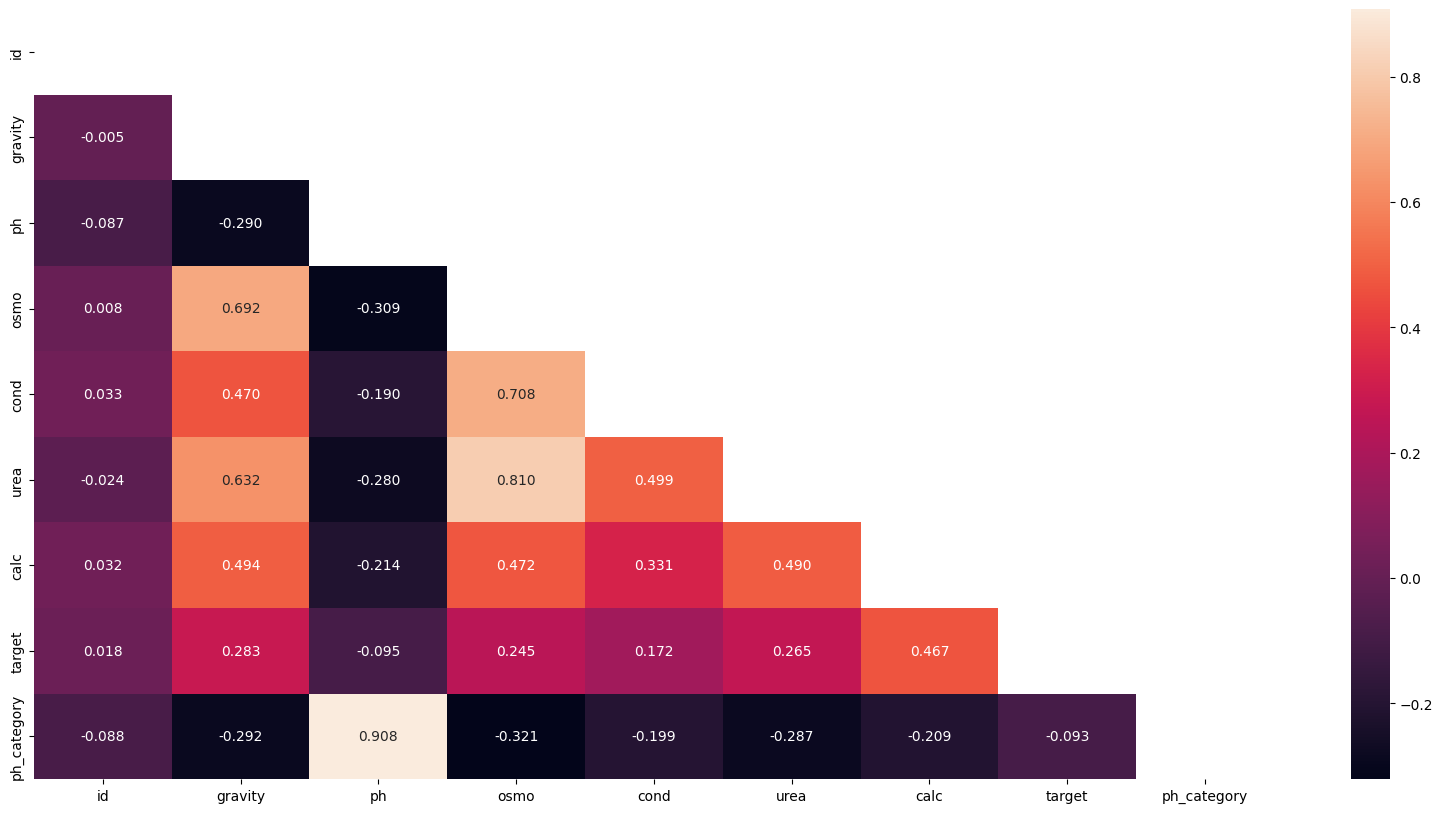

In [24]:
corr = train_df.corr()
mask = np.triu(corr)
ax, fig = plt.subplots(figsize = (20,10))
sns.heatmap(corr, mask = mask, annot = True, fmt=".3f")